<div style="text-align: center; padding: 30px; background-color: #f5f7fa; border-radius: 12px; box-shadow: 0px 4px 10px rgba(0,0,0,0.1);">

  <h1 style="color: #2c3e50; font-family: 'Helvetica Neue', sans-serif; font-size: 42px; margin-bottom: 10px;">
    Virtual Lab 8 Project
  </h1>

  <h3 style="color: #7f8c8d; font-family: 'Georgia', serif; font-weight: normal; font-size: 22px; margin-top: 0;">
    Interation Network Analysis
  </h3>

  <p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 16px; margin-top: 20px;">
    Author: <b>Vallari Eastman</b> <br>
    Due Date: <b>Monday November 3rd, 2025 11:59 p.m. ET</b>
  </p>
</div>

<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Introduction:
  </h2>
<p style="text-indent:30px; color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px; line-height:1.6;">
    This lab investigates the protein–protein interaction network of GRIN1, the gene encoding the NMDA receptor subunit NR1, using data from the BioPlex 3.0 database. By examining both validated and subthreshold interactions, the analysis explores how GRIN1 associates with proteins involved in cytoskeletal remodeling, ER-associated degradation, and membrane trafficking. These relationships provide insight into the broader cellular pathways that regulate NMDA receptor assembly, localization, and function within neuronal systems.
</p>


<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Methods:
  </h2>
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:0;">
    <b> Interaction Analysis Work Flow</b>
  </h3> 
   <p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px;">
       1. Search protein of interest on BioPlex Network <br>
       2. Analyze Protein relationships (bait, prey; direction) and interaction type (first neighbor, secondary, subthreshold)<br>
       3. Analyze high, medium, and low probability Protein-Protein Interactions<br>
       4. Using InterPro, find the PFam domains associated with your protein (can be found in the "Domain" section) <br>
       5. Hover over each domain to get the PFam designation. Using your protein name, search on the BioPlex Domains page<br>
   </p>
</div>

# Tutorial Section:

<h2 style="color: #2c3e50; font-family: 'Helvetica Neue', sans-serif; font-size: 32px; margin-bottom: 10px;">
    BioPlex Network
  </h2>

  <h4 style="color: #7f8c8d; font-family: 'Georgia', serif; font-weight: normal; font-size: 20px; margin-top: 0;">
    GRIN1
  </h4>

  <p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px;">
  </p>

<!-- Two figures aligned left and right with spacing -->
<div style="display: flex; justify-content: flex-start; align-items: flex-start; margin-top: 20px;"
    
  <!-- Figure 1 (left) -->
  <div style="width: 100%; margin-right: 50px; background-color: #ffffff; 
              border-radius: 12px; box-shadow: 0px 4px 8px rgba(0,0,0,0.15); padding: 12px;">

  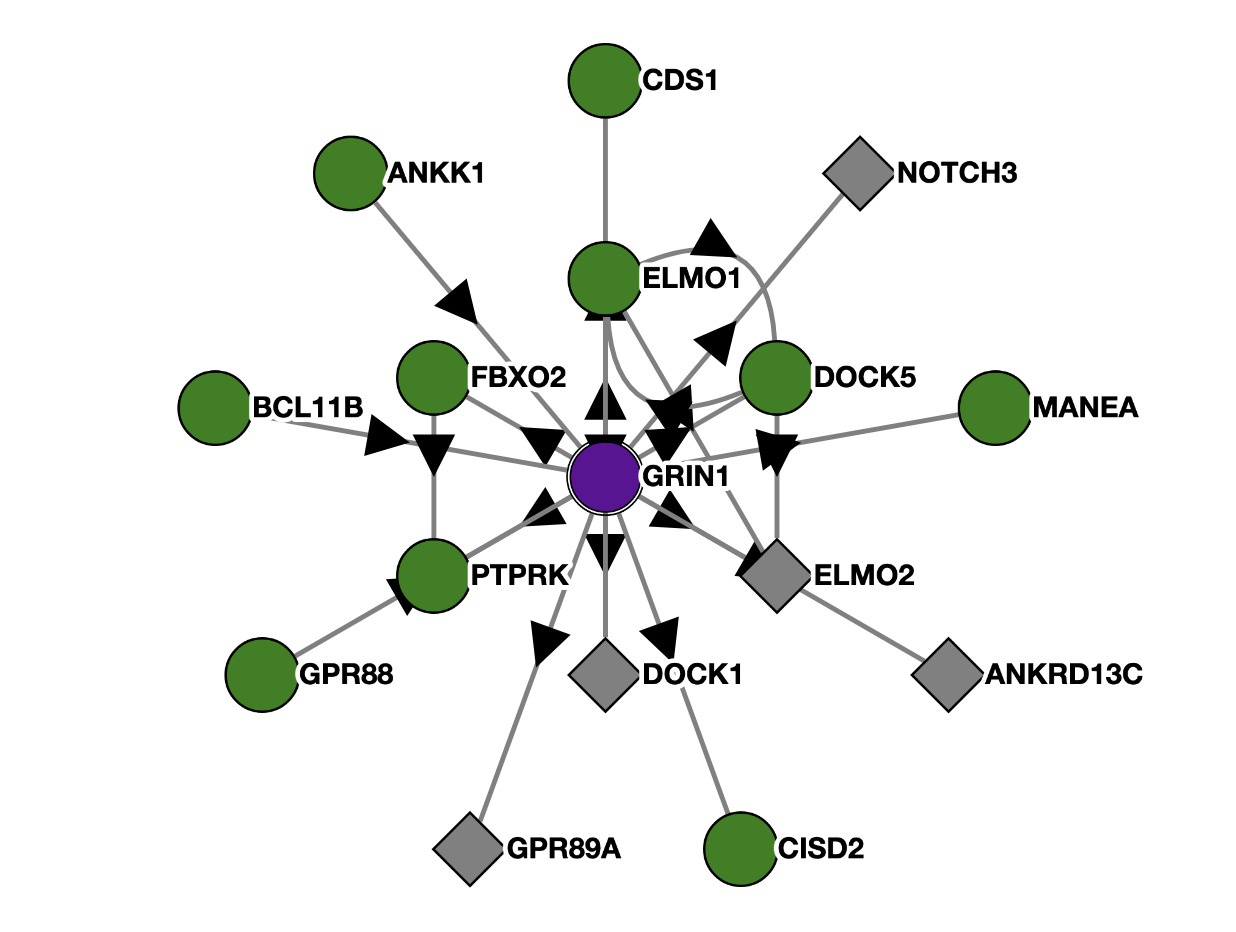

  <p style="font-family: 'Georgia', serif; font-size: 14px; color: #444; margin-top: 10px; text-align: left;">
      <b>Figure 1.</b> GRIN1 Interaction Network (BioPlex 3.0, Validated Interactions)</b>
    </p>
  </div>

  <!-- Figure 2 (right) -->
  <div style="width: 100%; background-color: #ffffff; 
              border-radius: 12px; box-shadow: 0px 4px 8px rgba(0,0,0,0.15); padding: 12px;">
   
  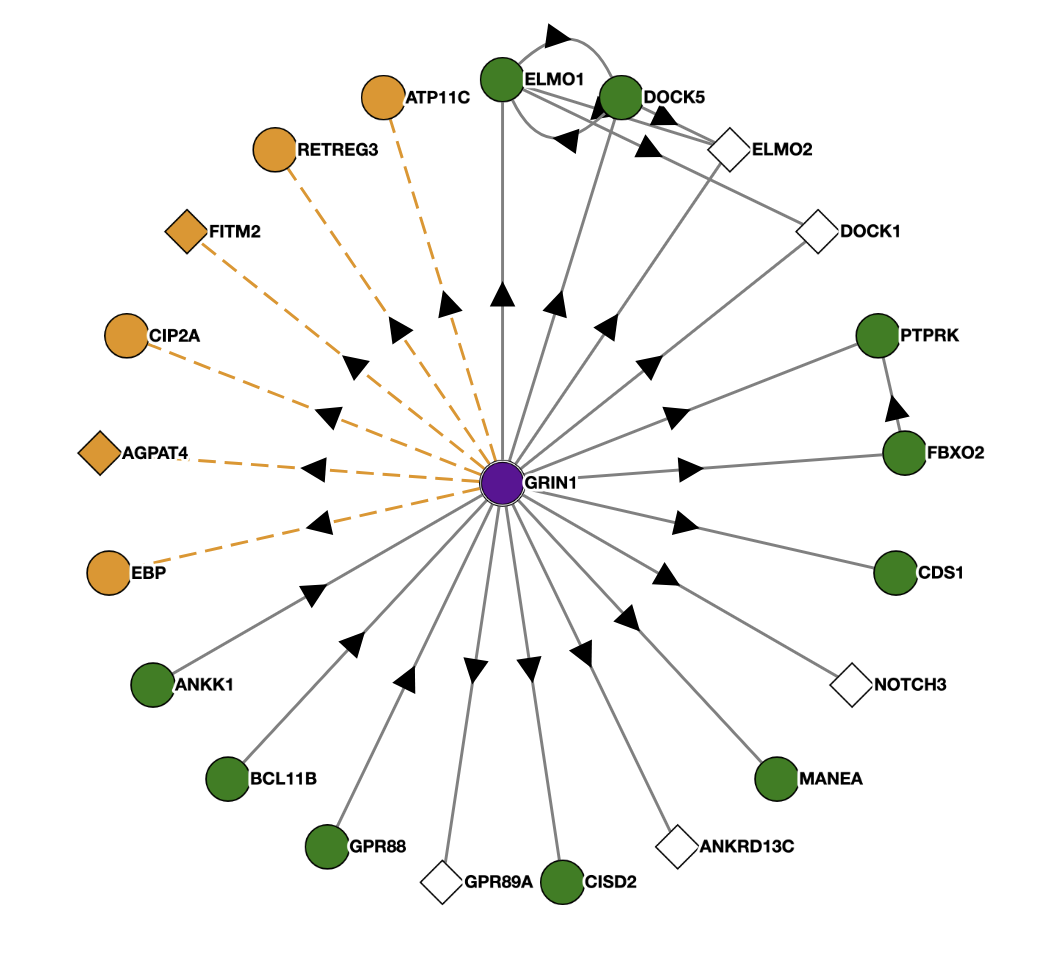

  <p style="font-family: 'Georgia', serif; font-size: 14px; color: #444; margin-top: 10px; text-align: left;">
      <b>Figure 2.</b> GRIN1 Subthreshold Interaction Network (BioPlex 3.0, Below Significance Threshold)</b>
      </p>
  </div>
</div>

In [1]:
# Scrollable table for BioPlex Table
from pathlib import Path
import pandas as pd
from IPython.display import HTML, display

def _load_table_safely(path: str) -> pd.DataFrame:
    """
    Robust loader for CSV/TSV/Excel/plain tables.
    Tries delimiter inference and common encodings.
    """
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"File not found: {path}")
    
    # Excel
    if p.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(p)
    
    # Try flexible CSV/TSV parsing
    try:
        return pd.read_csv(p, sep=None, engine="python")
    except UnicodeDecodeError:
        return pd.read_csv(p, sep=None, engine="python", encoding="latin-1")
    except Exception as e:
        # Fallbacks
        try:
            return pd.read_csv(p)  # assume comma
        except Exception:
            raise e

def show_scrollable_table(path: str, height: int = 480, width: str = "100%", sticky_header: bool = True, index: bool = False):
    """
    Render a pandas DataFrame inside a scrollable HTML container with an optional sticky header.
    """
    df = _load_table_safely(path)
    
    table_id = "scroll-table"
    html_table = df.to_html(index=index, escape=False, border=0, table_id=table_id)
    
    sticky_css = f"""
    #{table_id} thead th {{
        position: sticky;
        top: 0;
        background: #fafafa;
        z-index: 2;
        box-shadow: 0 1px 0 rgba(0,0,0,0.05);
    }}
    """ if sticky_header else ""
    
    style = f"""
    <style>
    .scroll-wrap {{
        max-height: {height}px;
        overflow: auto;           /* enables both vertical & horizontal scrolling */
        border: 1px solid #e5e7eb;
        border-radius: 10px;
        background: white;
    }}
    #{table_id} {{
        border-collapse: collapse;
        width: 100%;
        font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial, 'Apple Color Emoji','Segoe UI Emoji';
        font-size: 14px;
        table-layout: auto;
        white-space: nowrap;      /* prevent text wrap so horizontal scroll works */
    }}
    #{table_id} th, #{table_id} td {{
        padding: 8px 10px;
        border-bottom: 1px solid #f2f2f2;
        text-align: left;
    }}
    #{table_id} tbody tr:nth-child(even) {{ background: #fcfcfc; }}
    {sticky_css}
    </style>
    """
    
    container = f'<div class="scroll-wrap" style="width:{width}">{html_table}</div>'
    display(HTML(style + container))

# --- Use it on your uploaded file ---
show_scrollable_table(
    "GRIN1_Node-Table.csv",
    height=480,   # adjust height (px)
    width="100%", # or "900px"
    sticky_header=True,
    index=False
)


A-B,A,B,A.1,B.1,A.2,B.2,Networks,Wrong,pNI,pInt
2902-1793,1793,2902,Gene Link,Gene Link,DOCK1,GRIN1,BioPlex_3_0,0.0000,0.0001,0.9999
2902-81573,81573,2902,Gene Link,Gene Link,ANKRD13C,GRIN1,BioPlex_3_0,0.0000,0.0001,0.9999
2902-1040,1040,2902,Gene Link,Gene Link,CDS1,GRIN1,BioPlex_3_0,0.0000,0.0002,0.9998
2902-63916,63916,2902,Gene Link,Gene Link,ELMO2,GRIN1,BioPlex_3_0,0.0000,0.0004,0.9996
2902-9844,9844,2902,Gene Link,Gene Link,ELMO1,GRIN1,BioPlex_3_0,0.0072,0.0007,0.9921
255239-2902,2902,255239,Gene Link,Gene Link,GRIN1,ANKK1,BioPlex_3_0,0.0000,0.0045,0.9955
64919-2902,2902,64919,Gene Link,Gene Link,GRIN1,BCL11B,BioPlex_3_0,0.0000,0.0104,0.9896
2902-80005,80005,2902,Gene Link,Gene Link,DOCK5,GRIN1,BioPlex_3_0,0.0057,0.0197,0.9746
54112-2902,2902,54112,Gene Link,Gene Link,GRIN1,GPR88,BioPlex_3_0,0.0000,0.0294,0.9706
2902-493856,493856,2902,Gene Link,Gene Link,CISD2,GRIN1,BioPlex_3_0,0.0030,0.0402,0.9568


<div style=" padding: 25px; background-color: #f5f7fa; border-radius: 12px; box-shadow: 0px 4px 8px rgba(0,0,0,0.08); margin-top: 30px;">
<br>
  <h2 style="color: #2c3e50; font-family: 'Helvetica Neue', sans-serif; font-size: 28px; margin-bottom: 10px;">
    Protein Interactions of Interest:
  </h2>
<br><br>
<h4 style="text-align:left;color:#2c3e50;font-family:'Helvetica Neue',Arial,sans-serif;font-size:18px;margin-top:0;">
  <span style="color:#6a1b9a;font-weight:450;">GRIN1</span>
  &rarr;
  <span style="color:#808080;font-weight:450;">DOCK1</span>
  <span style="color:#2c3e50;font-weight:325;">(P: 99.98%)</span>
</h4>

  <p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px;">
    <b>Interaction:</b>
      <br>
      DOCK1 is represented as a grey diamond, meaning it was detected as a prey protein in a BioPlex AP-MS experiment (not used as bait itself). Its grey color shows that the interaction was observed. The arrow from GRIN1 to DOCK1 means GRIN1 was the bait and DOCK1 was pulled down with it, suggesting a potential physical or indirect association.
      <br><br>
      <b>Functions:</b>
      <br>
      DOCK1 helps control cytoskeletal changes needed for cell movement and for clearing dead cells. Together with CRK/CRKL, it supports epithelial and endothelial cell spreading and migration on type IV collagen. It acts as a guanine nucleotide exchange factor (GEF) that activates Rac GTPases by swapping GDP for GTP, and this activity is strengthened by ELMO1.
      <br><br>
      <b>Location:</b>
      <br>
      According to UniProt, DOCK1 is primarily localized in the cytoplasm and can be recruited to the cell membrane through its interaction with phosphatidylinositol 3,4,5-trisphosphate. Gene Ontology (GO) annotations further indicate that DOCK1 is present in the cytosol, cell membrane, and within neuronal structures such as presynaptic clusters, postsynaptic densities, and glutamatergic synapses.
      <br><br>
      <b>Relation to GRIN1:</b><br>
The interaction between GRIN1 and DOCK1 may link NMDA receptor signaling to downstream cytoskeletal remodeling. GRIN1, a core NMDA receptor subunit, anchors at postsynaptic densities where it regulates calcium influx and synaptic plasticity. DOCK1’s localization at the cell membrane and postsynaptic regions suggests it could mediate actin cytoskeleton reorganization in response to NMDA receptor activation. This implies that DOCK1 might function as part of a signaling cascade connecting GRIN1 activity to changes in neuronal connectivity, synapse stabilization, or plasticity.
  </p>
  
<hr style="border: none; border-top: 1px solid #ccc; margin: 20px 0;">

<h4 style="text-align:left;color:#2c3e50;font-family:'Helvetica Neue',Arial,sans-serif;font-size:18px;margin-top:0;">
  <span style="color:#6a1b9a;font-weight:450;">GRIN1</span>
  &larr;
  <span style="color:#808080;font-weight:450;">ANKRD13C</span>
  <span style="color:#2c3e50;font-weight:325;">(P: 99.96%)</span>
</h4>

  <p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px;">
    <b>Interaction:</b>
      <br>
      ANKRD13C is shown as a grey diamond, indicating it was detected as a prey protein in a BioPlex AP-MS experiment (not used as bait). Its grey color means the interaction was observed but not reciprocally confirmed. The arrow from GRIN1 to ANKRD13C signifies that GRIN1 was the bait, and ANKRD13C was pulled down with it, suggesting a possible physical or indirect association.
      <br><br>
      <b>Functions:</b>
      <br>
      Functions as a molecular chaperone for G protein-coupled receptors, guiding their proper folding, assembly, and transport from the endoplasmic reticulum.
      <br><br>
      <b>Location</b>
      <br>
      ANKRD13C is primarily associated with the cytosolic face of the endoplasmic reticulum.
      <br><br>
      <b>Relation to GRIN1:</b><br>
      This interaction suggests that ANKRD13C could influence GRIN1’s folding, trafficking, or membrane localization, particularly during receptor assembly or export from the ER. Since GRIN1 is a membrane receptor subunit, its association with a chaperone-like protein such as ANKRD13C may reflect a role in quality control or early trafficking of NMDA receptor complexes.
      <br>
  </p>

  <hr style="border: none; border-top: 1px solid #ccc; margin: 20px 0;">
  
<h4 style="text-align:left;color:#2c3e50;font-family:'Helvetica Neue',Arial,sans-serif;font-size:18px;margin-top:0;">
  <span style="color:#6a1b9a;font-weight:500;">GRIN1</span>
  &rarr;
  <span style="color:#808080;font-weight:450;">NOTCH3</span>
  <span style="color:#2c3e50;font-weight:400;">(P: 82.37%)</span>
</h4>

  <p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px;">
    <b>Interaction:</b>
      <br>
      NOTCH3 is represented as a grey diamond, meaning it was detected as a prey protein in a BioPlex AP-MS experiment (not used as bait itself). Its grey color shows that the interaction was observed. The arrow from GRIN1 to NOTCH3 means GRIN1 was the bait and DOCK1 was pulled down with it, suggesting a potential physical or indirect association.
      <br><br>
      <b>Functions:</b>
      <br>
      NOTCH3 acts as a receptor for membrane-bound ligands such as Jagged1, Jagged2, and Delta1, regulating cell fate decisions. Upon ligand binding, the receptor undergoes proteolytic cleavage, releasing the Notch intracellular domain (NICD), which translocates to the nucleus. There, NICD associates with RBPJ/RBPSUH to form a transcriptional activator complex that drives the expression of genes involved in differentiation, proliferation, and apoptosis.
      <br><br>
      <b>Location</b>
      <br>
      NOTCH3 is localized mainly at the plasma membrane and, following activation, its NICD fragment accumulates in the nucleus. GO annotations further identify localization to the cytosol, endoplasmic reticulum membrane, Golgi membrane, and nucleoplasm.
      <br><br>
      <b>Relation to GRIN1:</b><br>
      The potential interaction between NOTCH3 and GRIN1 may connect synaptic signaling to transcriptional regulation. While GRIN1 mediates calcium influx at excitatory synapses, NOTCH3 signaling can influence gene expression pathways that shape neuronal differentiation and survival. Their association could therefore reflect a functional link between NMDA receptor activity and downstream gene regulatory or developmental processes in neurons.
      <br>
  </p>

<hr style="border: none; border-top: 1px solid #ccc; margin: 20px 0;">

<h4 style="text-align:left;color:#2c3e50;font-family:'Helvetica Neue',Arial,sans-serif;font-size:18px;margin-top:0;">
  <span style="color:#6a1b9a;font-weight:450;">GRIN1</span>
  &rarr;
  <span style="color:#008000;font-weight:450;">FBX02</span>
  <span style="color:#2c3e50;font-weight:325;">(P: 77.72%)</span>
</h4>

  <p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px;">
    <b>Interaction:</b>
      <br>
     FBXO2 is represented as a green circle, indicating it was used as a bait protein in a BioPlex AP-MS experiment. The arrow from FBXO2 to GRIN1 shows that FBXO2 was the bait, and GRIN1 was pulled down with it, suggesting a potential physical or indirect association between the two proteins.
      <br><br>
      <b>Functions:</b>
      <br>
      FBX02 functions as the substrate recognition component of an SCF (SKP1–CUL1–F-box) E3 ubiquitin ligase complex, directing the ubiquitination and proteasomal degradation of specific target proteins. It participates in the endoplasmic reticulum–associated degradation (ERAD) pathway by identifying misfolded glycoproteins that have been retrotranslocated from the ER lumen into the cytosol. By binding to high-mannose–type sugar chains on these unfolded proteins, it promotes their ubiquitination and prevents the accumulation of cytosolic aggregates.
      <br><br>
      <b>Location</b>
      <br>
      It is localized to the cytoplasm and microsomal membrane. Gene Ontology (GO) annotations further indicate its presence in the cytosol, dendritic spines, endoplasmic reticulum, postsynaptic membrane, and glutamatergic synapses.
      <br><br>
      <b>Relation to GRIN1:</b><br>
      This localization pattern suggests that FBXO2 and GRIN1 may interact within overlapping neuronal compartments, particularly at postsynaptic sites. Since GRIN1 is a core subunit of the NMDA receptor located at the postsynaptic membrane of glutamatergic synapses, and FBXO2 functions in ER-associated degradation (ERAD) and protein quality control, their association could reflect a role for FBXO2 in regulating the stability, folding, or turnover of GRIN1 or other NMDA receptor subunits. In other words, FBXO2 may help ensure proper processing and degradation of misfolded or excess GRIN1 before or after it reaches the synaptic membrane, linking proteostasis mechanisms to synaptic receptor regulation.
  </p>

<hr style="border: none; border-top: 1px solid #ccc; margin: 20px 0;">

<h4 style="text-align:left;color:#2c3e50;font-family:'Helvetica Neue',Arial,sans-serif;font-size:18px;margin-top:0;">
  <span style="color:#6a1b9a;font-weight:450;">GRIN1</span>
  &rarr;
  <span style="color:#F0B000;font-weight:450;">RETREG3</span>
  <span style="color:#2c3e50;font-weight:325;">(P: 64.24%)</span>
</h4>

  <p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px;">
   <b>Interaction:</b>
      <br>
RETREG3 is represented as a yellow circle, indicating it was used as a bait protein in a BioPlex AP-MS experiment but that the interaction with GRIN1 was below the standard significance threshold. The yellow color signifies a subthreshold interaction, meaning it did not meet the confidence criteria for a validated BioPlex interaction but was still detected experimentally. The arrow from RETREG3 to GRIN1 shows that RETREG3 was the bait, and GRIN1 was pulled down with it, suggesting a possible weak or condition-dependent association between the two proteins.
      <br><br>
      <b>Functions:</b>
      <br>
      RETREG3 functions as an ER-anchored regulator of autophagy that remains inactive under normal conditions but becomes activated in response to cellular stress. Upon activation, it promotes ER fragmentation and facilitates the delivery of ER fragments to lysosomes by interacting with ATG8 family proteins. It contributes to ER membrane curvature and tubulation, processes essential for ER fragmentation and autophagosome formation. Additionally, it is involved in collagen quality control in a manner dependent on its LIR motif and plays a role in NRF1-enhanced neurite outgrowth.
      <br><br>
      <b>Location:</b>
      <br>
      RETREG3 is a membrane-associated protein that localizes primarily to the tubular regions and sheet edges of the endoplasmic reticulum.
      <br><br>
      <b>Relation to GRIN1:</b><br>
      RETREG3 and GRIN1 may be functionally linked through endoplasmic reticulum (ER) quality control and stress response pathways. Since RETREG3 is an ER-anchored autophagy regulator that mediates ER fragmentation and delivery to lysosomes, and GRIN1 is an ER-processed membrane receptor subunit that requires proper folding and trafficking to reach the postsynaptic membrane, their association could reflect a role for RETREG3 in monitoring or facilitating the turnover of misfolded or excess GRIN1.
  </p>

<hr style="border: none; border-top: 1px solid #ccc; margin: 20px 0;">

<h4 style="text-align:left;color:#2c3e50;font-family:'Helvetica Neue',Arial,sans-serif;font-size:18px;margin-top:0;">
  <span style="color:#6a1b9a;font-weight:450;">GRIN1</span>
  &rarr;
  <span style="color:#F0B000;font-weight:450;">FITM2</span>
  <span style="color:#2c3e50;font-weight:325;">(P: 51.45%)</span>
</h4>
  <p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px;">
    <b>Interaction:</b>
      <br>
      FITM2 is represented as a yellow diamond, meaning it was detected as a prey protein in a BioPlex AP-MS experiment, but that the interaction with GRIN1 was below the standard significance threshold. The yellow color signifies a subthreshold interaction, meaning it did not meet the confidence criteria for a validated BioPlex interaction but was still detected experimentally. The arrow from GRIN1 to FITM2 shows that GRIN1 was the bait, and FITM2 was pulled down with it, suggesting a possible weak or condition-dependent association between the two proteins.
      <br><br>
      <b>Functions:</b>
      <br>
      FITM2 functions as a fatty acyl–CoA diphosphatase, catalyzing the hydrolysis of fatty acyl–CoA molecules to produce acyl-4'-phosphopantetheine and adenosine 3',5'-bisphosphate. It preferentially acts on unsaturated long-chain acyl–CoA substrates, such as oleoyl-CoA and arachidonoyl-CoA, within the endoplasmic reticulum (ER) lumen. This enzymatic activity is essential for maintaining ER structure and supporting the biogenesis of lipid droplets (LDs)—organelles responsible for lipid and energy storage. The protein directly binds to diacylglycerol (DAG) and triacylglycerol (TAG), interactions that promote lipid droplet formation by modulating DAG levels at budding sites. Additionally, it contributes to the regulation of cell morphology and cytoskeletal organization.
      <br><br>
      <b>Location</b>
      <br>
      FITM2 is a multi-pass membrane protein that localizes to the endoplasmic reticulum.
      <br><br>
      <b>Relation to GRIN1:</b>
      <br>
      FITM2 and GRIN1 may be connected through endoplasmic reticulum (ER)–based membrane processing and trafficking pathways. Since FITM2 is an ER-resident multi-pass membrane protein involved in lipid droplet formation and ER membrane organization, and GRIN1 is synthesized and folded within the ER before being transported to the postsynaptic membrane, their interaction could reflect a role for FITM2 in maintaining the membrane environment or lipid composition necessary for proper folding, assembly, or trafficking of GRIN1.
  </p>

<h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Domains
  </h2>
  
<!-- Figure 3 -->
<div style="background-color: #ffffff; border-radius: 12px; 
            box-shadow: 0px 4px 8px rgba(0,0,0,0.15); padding: 12px;">

  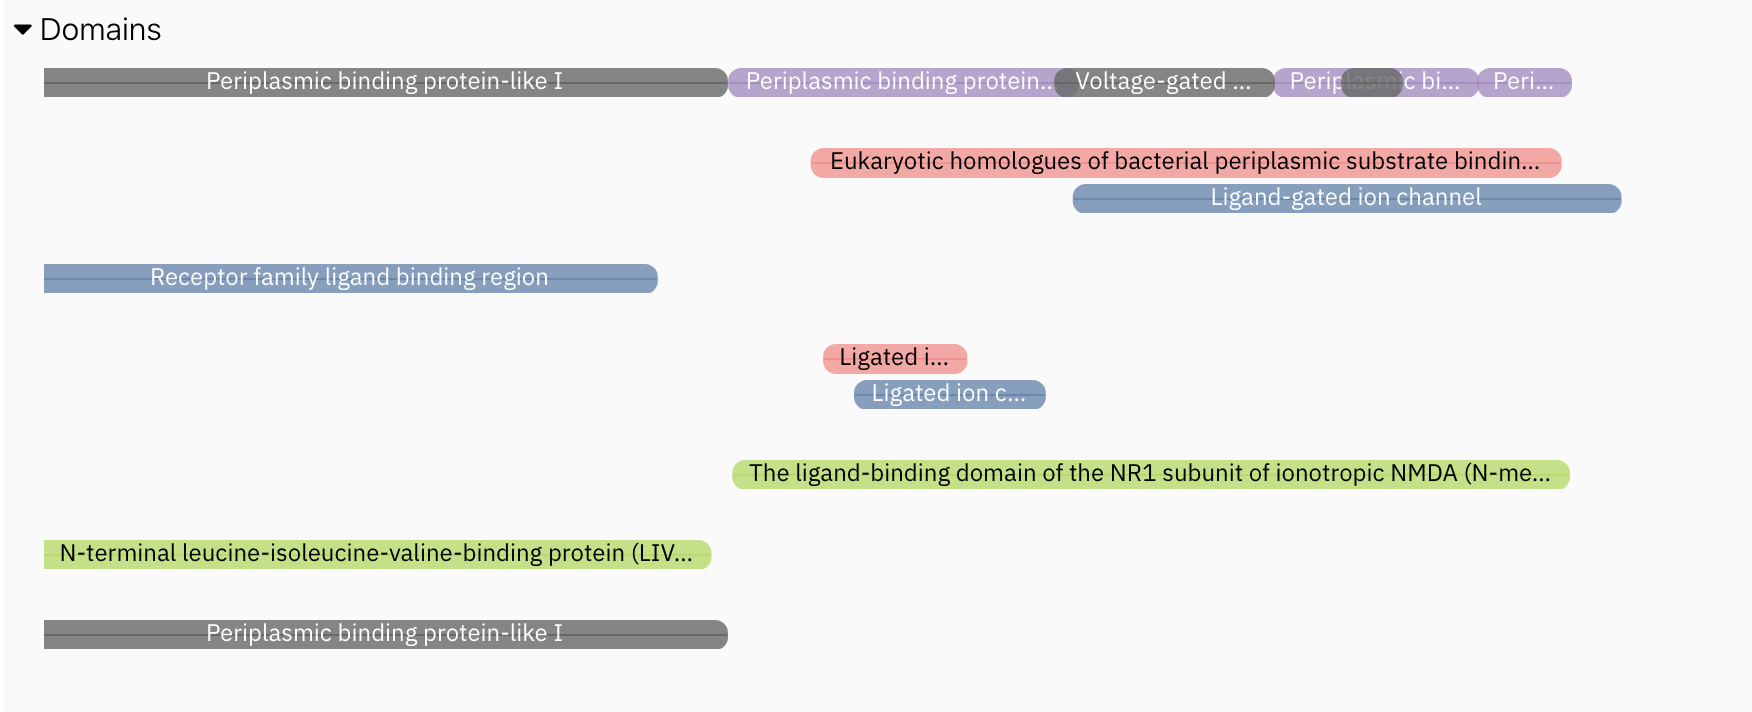

  <p style="font-family: 'Georgia', serif; font-size: 14px; color: #444; margin-top: 10px;">
    <b>Figure 3. GRIN1 protein domain architecture from Pfam and InterPro annotations.</b><br>
    This schematic shows the predicted functional domains within the GRIN1 (NMDA receptor subunit NR1) sequence.
    The protein contains multiple periplasmic binding protein-like (PBPI and PBPII) domains that contribute to its
    ligand-binding domain (LBD), characteristic of ionotropic glutamate receptors. Overlapping annotations identify
    a receptor family ligand-binding region and a ligand-gated ion channel domain, consistent with GRIN1’s role in
    glutamate recognition and ion channel gating. The presence of the NR1-specific ligand-binding domain (green)
    highlights the subunit’s essential contribution to NMDA receptor assembly and neurotransmission.
  </p>
</div>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    Periplasmic binding protein-like I (Integrated: IPR028082)
      SUPERFAMILY SSF53822 Periplasmic binding protein-like I Integrated: IPR028082
  </p>

<!-- RESULTS SECTION -->
<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Results
  </h2>

  <!-- SECTION 1 -->
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:10px;">
    Weak Correlation Between Predicted and Measured ddG:
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    The baseline regression model, which used only categorical features describing the wild-type residue, mutation type, and protein identifier, achieved a Pearson correlation coefficient of R = 0.12 between predicted and experimental ΔΔG values. Pearson R = 0.12 means that the correlation is barely above being considered completely random. It means there’s very weak linear correlation between predicted and measured ddG. The mean experimental stability change was 1.24 kcal/mol, while the mean predicted ΔΔG was slightly lower at 0.93 kcal/mol. This indicates that the model tends to underpredict stability changes relative to experimental measurements. The broad scatter of points around the diagonal in the plot reflects weak linear correlation between predicted and observed values. This is consistent with limited predictive power when structural context and sequence-level features are not incorporated.<br><br>
        The weak correlation (R ≈ 0.12) suggests the simple residue identity features are inadequate for capturing the complex energetic and structural determinants of protein stability. Without considering spatial environment, residue interactions, or dynamic flexibility, the model cannot distinguish stabilizing from destabilizing substitutions in a physically meaningful way. Biophysically, this outcome underscores that ΔΔG depends on local packing, hydrogen bonding, and long-range coupling—all features encoded in a protein’s 3D structure but lost when only categorical sequence labels are used. This baseline quantifies how little information exists in raw sequence identity alone, and establishes the need for more informative representations, such as pretrained sequence–structure embeddings, to capture the structural underpinnings of conformational stability and, by extension, large conformational changes.
  </p>

<!-- ANALYSIS SECTION -->
<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Analysis
  </h2>

  <!-- Question 1-->
  <h3 style="color:#2c3e50; font-family:'Georgia',serif; font-weight:normal; font-size:17px; margin-top:10px;">
    1. What criteria did you use to evaluate the performance of the model? What changes (if any) could be made to optimize the evaluation?
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    For this experiment, model performance was evaluated using the Pearson correlation coefficient (R) between the predicted ΔΔG values and the experimentally measured ΔΔG values across held-out test folds. Pearson R measures how well the model’s predictions vary linearly with the ground truth: an R of 1 means perfect linear agreement (model increases exactly when the true value increases), an R of 0 means no linear relationship. There are a few ways to improve or refine this evaluation. First, Pearson R tells you about correlation, but not about absolute accuracy. We could add regression error metrics such as mean absolute error (MAE, in kcal/mol) or root mean squared error (RMSE) to quantify how close the predicted ΔΔG values are in physical units. That matters because two models can have similar correlation but very different error magnitudes. Second, instead of reporting only one pooled R across all folds and seeds, we could summarize the per-fold distribution (median and variance across folds) to show robustness.<br><br>
  </p>

<!-- Question 2 -->
  <h3 style="color:#2c3e50; font-family:'Georgia',serif; font-weight:normal; font-size:17px; margin-top:10px;">
    2. How do you interpret the Pearson correlation scores that you generated? What conclusions about the structure and function of your generated mutants can you make based on this analysis?
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    The Pearson correlation coefficient of R = 0.12 indicates that there is only a weak linear relationship between the predicted and experimentally measured ΔΔG values. So, while the model captures a slight trend—mutations that are more destabilizing or stabilizing experimentally tend to be weakly mirrored in the predictions. It fails to explain most of the variance in the true data. This low correlation is expected for a baseline model that relies only on categorical mutation features without incorporating structural or contextual sequence information. The model is guessing based on residue identity alone, not on how the mutation alters the physical environment of the protein. <br><br>
        This result suggests that the generated mutants cannot be meaningfully differentiated in terms of their thermodynamic stability using simple identity-based descriptors. The weak correlation implies that key determinants of stability, such as residue burial, hydrogen bonding, side-chain packing, and conformational flexibility, are missing from the model’s representation. Therefore, we can conclude that the baseline model does not reflect the true energetic or structural impact of mutations.<br><br>
  </p>

  <!-- Question 3 -->
  <h3 style="color:#2c3e50; font-family:'Georgia',serif; font-weight:normal; font-size:17px; margin-top:10px;">
    3. What are the steps used for thermal stability predictions using this approach? Are there any assumptions that limit the broad applicability of the approach?
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    First, experimentally measured ΔΔG values for protein mutations are obtained from the FireProt thermostability database, which provides a benchmark set of stability data. Second, each protein sequence and its corresponding mutant are encoded as input features for a machine learning model. In the baseline version, these features are categorical variables, such as the wild-type residue, the mutant residue, and the protein identifier, encoded through one-hot representation. Third, a regression model (in this case, a multilayer perceptron regressor, or MLP) is trained using GroupKFold cross-validation, where mutations from different proteins are separated into distinct training and test sets to ensure generalization. The model is then evaluated by comparing predicted and experimental ΔΔG values using the Pearson correlation coefficient, which quantifies the strength of the linear relationship between the two. <br><br>
        Several assumptions limit the broad applicability of this approach. 1. The method assumes that linear correlations between embedding features and ΔΔG can adequately capture the complex, nonlinear energetics of protein stability. 2. The FireProt dataset is biased toward small, soluble, well-studied proteins, so that models trained on it may not generalize well to membrane proteins or large multidomain complexes. 3. Because ΔΔG values are treated as scalar labels, this approach ignores multi-state folding pathways and kinetic effects that can strongly influence stability in real biological systems.<br><br>
  </p>

<!-- Question 4 -->
  <h3 style="color:#2c3e50; font-family:'Georgia',serif; font-weight:normal; font-size:17px; margin-top:10px;">
    4. Are there sequence characteristics or limitations that would cause this analysis to fail? Can you think of conditions that would result in tremendously inaccurate stability calculations? Why or why not?
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    Sequences with low evolutionary conservation or intrinsically disordered regions often lead to unreliable predictions. The embedding models (and even baseline residue-based regressors) assume that amino acids exist in a well-defined structural environment. Disordered or highly flexible regions violate the assumption that their residues do not have stable 3D interactions to capture, so any sequence-based feature (even an embedding) cannot meaningfully relate to ΔΔG. <br><br>
        Multimeric proteins, membrane proteins, and allosteric enzymes pose challenges because the models typically treat each sequence as a single, folded monomer in isolation. Mutations that affect subunit interfaces, lipid interactions, or ligand binding sites can have disproportionate energetic effects that are not captured by a single-chain embedding.<br><br>
        The analysis is most reliable for small, globular, single-domain proteins with well-structured folds and isolated point mutations. It becomes inaccurate when sequence features fail to map cleanly to a single, stable structural context (e.g. flexible, multimeric, membrane-associated, or allosterically regulated systems) because those violate the core assumptions underlying both the baseline and embedding-based ΔΔG prediction approaches.
  </p>

<!-- NEXT STEPS SECTION -->
<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Next Steps
  </h2>

  <!-- SECTION 1 -->
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:10px;">
    Prediction of Large Conformational Changes
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    The next phase of this study will extend beyond single-point stability predictions to investigate how sequence–structure embeddings can capture and differentiate large-scale conformational states. First, the pretrained model will be applied to sets of experimentally resolved conformers, such as open and closed structures or ligand-bound and unbound states, to quantify embedding-space shifts associated with domain motion or hinge flexibility. Embedding differences will then be mapped onto structural coordinates to identify regions with the highest conformational variability, such as loop regions, interfaces, or allosteric sites. In parallel, molecular dynamics or normal mode analysis can be used to validate whether residues showing large embedding deviations correspond to experimentally observed flexible regions. Ultimately, integrating ΔΔG-based stability predictions with embedding-derived conformational metrics will provide a data-driven framework for predicting and visualizing large conformational changes directly from sequence information.
  </p>

<!-- REFERENCES SECTION -->
<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    References
  </h2>

  <!-- SECTION 1 -->
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:10px;">
    Proteins of Interest:
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    UniProt. (2025). DOCK1 - Dedicator of cytokinesis protein 1 - Homo sapiens (Human). UniProtKB. Retrieved from https://www.uniprot.org/uniprotkb/Q14185/entry#function<br><br>
      UniProt. (2025). RETREG3 – Reticulophagy regulator 3 – Homo sapiens (Human). UniProtKB. Retrieved from https://www.uniprot.org/uniprotkb/Q8N6S4/entry#function
<br><br>
UniProt. (2025). FBXO2 – F-box only protein 2 – Homo sapiens (Human). UniProtKB. Retrieved from https://www.uniprot.org/uniprotkb/Q9UM47/entry#function
<br><br>
UniProt. (2025). NOTCH3 – Neurogenic locus notch homolog protein 3 – Homo sapiens (Human). UniProtKB. Retrieved from https://www.uniprot.org/uniprotkb/Q9UK22/entry#function
<br><br>
UniProt. (2025). FITM2 – Acyl-coenzyme A diphosphatase FITM2 – Homo sapiens (Human). UniProtKB. Retrieved from https://www.uniprot.org/uniprotkb/Q8N6M3/entry#function
<br><br>
UniProt. (2025). ANKRD13C – Ankyrin repeat domain-containing protein 13C – Homo sapiens (Human). UniProtKB. Retrieved from https://www.uniprot.org/uniprotkb/Q8N6M3/entry#function
  </p>

  <!-- SECTION 1 -->
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:10px;">
    Databases:
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:hanging;">
    Introduction to PDB Data. (RCSB PDB is funded by the National Science Foundation (DBI-1832184), the US Department of Energy (DE-SC0019749), and the National Cancer Institute, National Institute of Allergy and Infectious Diseases, and National Institute of General Medical Sciences o) Retrieved from RCSB PDB-101 - Molecular explorations through biology and medicine. The educational portal of Protein Data Base (PDB): https://pdb101.rcsb.org/learn/guide-to-understanding-pdb-data/introductionLinks to an external site.
<br><br>
Huttlin, E. L., Bruckner, R. J., Navarrete-Perea, J., Cannon, J. R., Baltier, K., Gebreab, F., ... & Gygi, S. P. (2021). Dual proteome-scale networks reveal cell-specific remodeling of the human interactome. Cell , 184 (11), 3022-3040.
<br><br>
Schweppe, D. K., Huttlin, E. L., Harper, J. W., & Gygi, S. P. (2018). BioPlex display: an interactive suite for large-scale AP–MS protein–protein interaction data. Journal of proteome research , 17 (1), 722-726.
<br><br>
Blum, M., Chang, H. Y., Chuguransky, S., Grego, T., Kandasaamy, S., Mitchell, A., ... & Finn, R. D. (2021). The InterPro protein families and domains database: 20 years on. Nucleic acids research , 49 (D1), D344-D354.
  </p>